# Mortgage Default Risk Model — Expanded Features

Earlier analysis found that pairwise Pearson correlations among underwriting fields (credit score, DTI, LTV, rate) are all weak (<0.21), and even credit_score's correlation with `default_target` looks weak (-0.12) despite the fact that credit_score alone achieves **AUC 0.72** and a 5-field logistic regression reaches **AUC 0.75**. This notebook extends that baseline: more features, a gradient boosting model (LightGBM), and both ROC-AUC and PR-AUC (more informative than ROC-AUC for a ~2% base rate) on a held-out test set.

**Important methodological fix:** loans originated in 2024-2025 have had very little time to season, so their `default_target` is mostly right-censored (not "low risk", just "hasn't had time to default yet"). Including them as confirmed non-defaults would bias the model. We filter to loans with **at least 24 months of performance history** (`current_loan_age >= 24`) before training/evaluating.

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NUMERIC_FEATURES = [
    "credit_score", "original_dti", "original_upb", "original_cltv", "original_ltv",
    "original_interest_rate", "original_loan_term", "number_of_borrowers",
    "number_of_units", "mi_percent",
]
CATEGORICAL_FEATURES = [
    "occupancy_status", "property_type", "loan_purpose", "channel",
    "first_time_homebuyer_flag", "property_state",
]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "default_target"

DATA_GLOB = "../data/processed/loan_level/orig_year=*/orig_quarter=*/*.parquet"

df = (
    pl.scan_parquet(DATA_GLOB)
    .select(ALL_FEATURES + [TARGET, "current_loan_age", "orig_year", "orig_quarter"])
    .collect()
)
print(f"Loaded {df.height:,} loans")
df.head()

Loaded 12,213,996 loans


credit_score,original_dti,original_upb,original_cltv,original_ltv,original_interest_rate,original_loan_term,number_of_borrowers,number_of_units,mi_percent,occupancy_status,property_type,loan_purpose,channel,first_time_homebuyer_flag,property_state,default_target,current_loan_age,orig_year,orig_quarter
i64,f64,f64,f64,f64,f64,i64,i64,i64,f64,str,str,str,str,str,str,i32,i64,i32,str
784,25.0,385000.0,65.0,65.0,2.75,180,2,1,0.0,"""P""","""PU""","""N""","""R""","""N""","""CO""",0,65,2020,"""Q1"""
738,26.0,175000.0,64.0,64.0,3.375,240,2,1,0.0,"""P""","""SF""","""N""","""B""","""N""","""KY""",0,65,2020,"""Q1"""
770,25.0,424000.0,53.0,53.0,3.0,240,1,1,0.0,"""P""","""PU""","""N""","""B""","""N""","""CA""",0,9,2020,"""Q1"""
770,44.0,349000.0,89.0,89.0,3.375,360,1,1,25.0,"""P""","""PU""","""N""","""B""","""N""","""NC""",0,6,2020,"""Q1"""
721,35.0,412000.0,89.0,89.0,3.375,360,2,1,25.0,"""P""","""PU""","""N""","""B""","""N""","""NC""",0,15,2020,"""Q1"""


## Apply the seasoning filter and drop rows missing the target

In [2]:
before = df.height
seasoned = df.filter(pl.col("current_loan_age") >= 24).drop_nulls(subset=[TARGET])
print(f"Dropped {before - seasoned.height:,} rows with <24 months of history or missing target "
      f"({(before - seasoned.height) / before:.1%})")
print(f"Remaining: {seasoned.height:,} loans")
print()
print("Default rate before filter:", df[TARGET].mean())
print("Default rate after filter (seasoned only):", seasoned[TARGET].mean())

Dropped 3,478,294 rows with <24 months of history or missing target (28.5%)
Remaining: 8,735,702 loans

Default rate before filter: 0.01992009985266901
Default rate after filter (seasoned only): 0.020875941052018485


## Encode categoricals and split into train/test

LightGBM handles categorical columns natively (no one-hot needed) if they're cast to pandas' `category` dtype. Nulls are left as-is -- both LightGBM and the missing-indicator handling in logistic regression's imputer deal with them explicitly rather than silently.

In [3]:
from sklearn.model_selection import train_test_split

pdf = seasoned.select(ALL_FEATURES + [TARGET]).to_pandas()
for c in CATEGORICAL_FEATURES:
    pdf[c] = pdf[c].astype("category")

X = pdf[ALL_FEATURES]
y = pdf[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")
print(f"Train default rate: {y_train.mean():.4%}   Test default rate: {y_test.mean():.4%}")

Train: 6,988,561   Test: 1,747,141
Train default rate: 2.0876%   Test default rate: 2.0876%


## Baseline: logistic regression on the original 5 fields

Same approach as the earlier terminal check, now on the seasoned subset, for a fair comparison against the expanded model below.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

BASELINE_FIELDS = ["credit_score", "original_dti", "original_upb", "original_cltv", "original_interest_rate"]

baseline_model = make_pipeline(
    SimpleImputer(strategy="median"),
    LogisticRegression(max_iter=1000, class_weight="balanced"),
)
baseline_model.fit(X_train[BASELINE_FIELDS], y_train)
baseline_proba = baseline_model.predict_proba(X_test[BASELINE_FIELDS])[:, 1]

baseline_roc_auc = roc_auc_score(y_test, baseline_proba)
baseline_pr_auc = average_precision_score(y_test, baseline_proba)
print(f"Baseline (5 fields, logistic regression) -- ROC-AUC: {baseline_roc_auc:.4f}   PR-AUC: {baseline_pr_auc:.4f}")

Baseline (5 fields, logistic regression) -- ROC-AUC: 0.7213   PR-AUC: 0.0461


## Expanded model: LightGBM on all 16 fields

Gradient boosting captures non-linear effects and interactions that logistic regression can't (e.g. the credit-score/default relationship we saw earlier was clearly non-linear -- flat, then a steep drop). `class_weight`-equivalent handling via `scale_pos_weight` compensates for the ~2% default rate.

In [5]:
import lightgbm as lgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1,
)
lgb_model.fit(X_train, y_train, categorical_feature=CATEGORICAL_FEATURES)
lgb_proba = lgb_model.predict_proba(X_test)[:, 1]

lgb_roc_auc = roc_auc_score(y_test, lgb_proba)
lgb_pr_auc = average_precision_score(y_test, lgb_proba)
print(f"LightGBM (16 fields) -- ROC-AUC: {lgb_roc_auc:.4f}   PR-AUC: {lgb_pr_auc:.4f}")
print()
print(f"Improvement over baseline -- ROC-AUC: {lgb_roc_auc - baseline_roc_auc:+.4f}   PR-AUC: {lgb_pr_auc - baseline_pr_auc:+.4f}")

LightGBM (16 fields) -- ROC-AUC: 0.8002   PR-AUC: 0.0823

Improvement over baseline -- ROC-AUC: +0.0789   PR-AUC: +0.0362


## ROC and Precision-Recall curves, baseline vs. expanded model

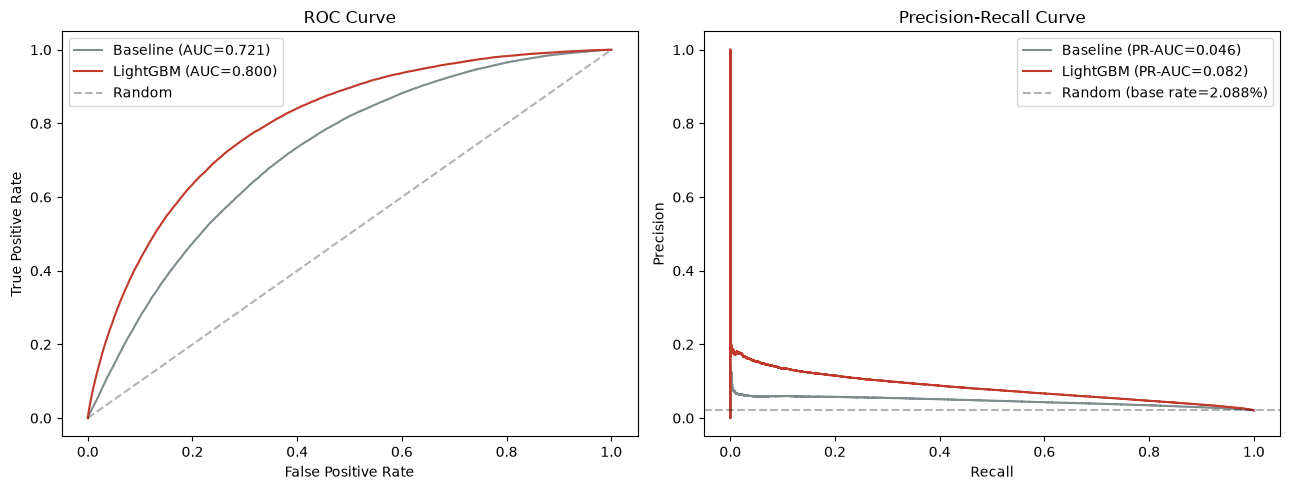

In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr_b, tpr_b, _ = roc_curve(y_test, baseline_proba)
fpr_l, tpr_l, _ = roc_curve(y_test, lgb_proba)
axes[0].plot(fpr_b, tpr_b, label=f"Baseline (AUC={baseline_roc_auc:.3f})", color="#7f8c8d")
axes[0].plot(fpr_l, tpr_l, label=f"LightGBM (AUC={lgb_roc_auc:.3f})", color="#c0392b")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

prec_b, rec_b, _ = precision_recall_curve(y_test, baseline_proba)
prec_l, rec_l, _ = precision_recall_curve(y_test, lgb_proba)
axes[1].plot(rec_b, prec_b, label=f"Baseline (PR-AUC={baseline_pr_auc:.3f})", color="#7f8c8d")
axes[1].plot(rec_l, prec_l, label=f"LightGBM (PR-AUC={lgb_pr_auc:.3f})", color="#c0392b")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.3, label=f"Random (base rate={y_test.mean():.3%})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

fig.tight_layout()
plt.show()

## Feature importance (LightGBM)

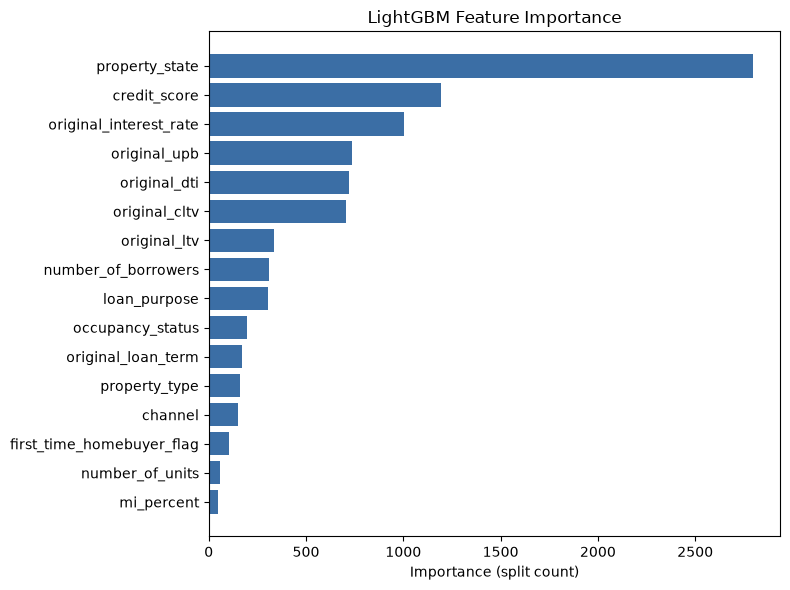

,feature,importance
15,property_state,2796
0,credit_score,1193
5,original_interest_rate,1006
2,original_upb,736
1,original_dti,719
3,original_cltv,708
4,original_ltv,336
7,number_of_borrowers,312
12,loan_purpose,304
10,occupancy_status,196


In [7]:
importance = pd.DataFrame({
    "feature": ALL_FEATURES,
    "importance": lgb_model.feature_importances_,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance["feature"], importance["importance"], color="#3b6ea5")
ax.set_xlabel("Importance (split count)")
ax.set_title("LightGBM Feature Importance")
fig.tight_layout()
plt.show()

importance.sort_values("importance", ascending=False)